In [67]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import tkinter as tk
from tkinter import filedialog, ttk

In [68]:
input_dir = "test-images"
output_dir = "output-sketches"

color_mode = True  # Set to True for color sketches, False for grayscale sketches


In [69]:
def pencil_sketch(img_path, blur_ksize = 41):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {img_path}")
    #kernel size should be odd and greater than 1
    #no need to check here as user will provide correct value from the slider
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #convert color of image from BGR to GRAY
    img_invert = cv2.bitwise_not(img_gray) #invert the gray image
    img_smooth = cv2.GaussianBlur(img_invert, (blur_ksize, blur_ksize), 0) #cv2.GaussianBlur(src, ksize, sigmaX) sigmaX is standard deviation in X direction, here 0 means calculated from kernel size

    #now invert the blurred image
    img_smooth_invert = cv2.bitwise_not(img_smooth)
    #create the pencil sketch image:
    img_pencil_sketch = cv2.divide(img_gray, img_smooth_invert, scale = 256)
    if not color_mode:
        return img, img_pencil_sketch
    
    #create color pencil sketch
    img_color_pencil_sketch = cv2.bitwise_and(img, img, mask=cv2.bitwise_not(img_pencil_sketch))
    threshold = 1  # adjust
    mask = cv2.inRange(img_color_pencil_sketch, (0, 0, 0), (threshold, threshold, threshold))
    img_color_pencil_sketch[mask > 0] = (255, 255, 255)

    return (img, img_color_pencil_sketch)

    

#### The core of this effect
is the cv2.divide function. It implements a Color Dodge blend mode. Mathematically, it looks like this

$$Result = \frac{Grayscale}{Inverted Blurred}\times 256$$

By dividing the grayscale pixels by the inverted blurred pixels, we highlight the sharpest edges (where the difference between the original and the blur is greatest) and flatten the rest to white.

#### Now for the coloring part
##### A. Binary Logic
like the one i have implemented
##### B. Linear Blending
Instead of a binary "yes or no" logic (bitwise), we should use Multiplication or Weighted Blending. This treats the sketch as a texture that darkens the colors of the original image.

The formula we want is:
$$Result = \frac{Pencil Sketch\times Original Color}{256}$$


In [70]:
def display_img(original, sketch, save_path = None):
    # plt.figure(figsize = (10,10)) #set figure size to 10x10 inches
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Original Image')
    plt.subplot(1,2,2)
    if color_mode:
        plt.imshow(cv2.cvtColor(sketch, cv2.COLOR_BGR2RGB), cmap=None)
    else:
        plt.imshow(sketch, cmap = 'gray')
    plt.axis('off')
    plt.title('Pencil Sketch Image')
    plt.show()

    if save_path:
        cv2.imwrite(save_path, sketch)
        print(f"Pencil sketch image saved at: {save_path}")

In [71]:
def main():
    img_path = input("Enter the file name of the image: ").strip()
    if not img_path:
        img_path = 'sample_image2.jpeg'
        
    img_path = os.path.join(input_dir, img_path)
    print(f"Processing image: {img_path}")
    original, sketch = pencil_sketch(img_path)
    display_img(original, sketch, save_path = os.path.join(output_dir, 'color_'*color_mode+'pencil_sketch_'+ os.path.basename(img_path)))

Processing image: test-images\sample_image2.jpeg


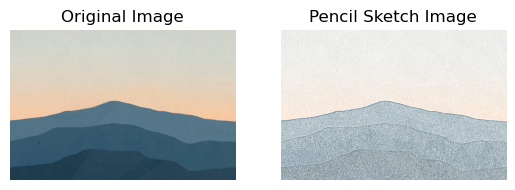

Pencil sketch image saved at: output-sketches\color_pencil_sketch_sample_image2.jpeg


In [72]:
if __name__ == "__main__":
    ## CLI verison
    main()
